<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/RC%20example%20model%20State%20Space%20System%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# --- Colab Setup ---
# Install the rescompy library from GitHub
!pip install git+https://github.com/PotomacResearch/rescompy.git --quiet

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import rescompy as rc
import rescompy.plotter

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


https://github.com/PotomacResearch/rescompy

=== Understanding Reservoir Computing ===

1. Introduction:
   Reservoir Computing (RC) is a machine learning framework designed for processing temporal data,
   especially useful for tasks involving recurrent neural networks (RNNs) like time series prediction.

2. Core Components:
   a. Input Layer: Takes the external input signal and feeds it into the reservoir.
   b. Reservoir (Hidden Layer): A large, fixed, randomly connected recurrent neural network.
      - It has internal dynamics that respond to the input.
      - The connections within the reservoir are typically random and remain unchanged during training.
      - It's called a 'reservoir' because it holds a rich history of the input signal's influence.
   c. Output (Readout) Layer: A typically linear model (like Ridge Regression) that is trained to map
      the reservoir's internal states to the desired output.

3. Process:
   i.  Initialization: The reservoir's internal connections (weights) and bias are randomly set.
    

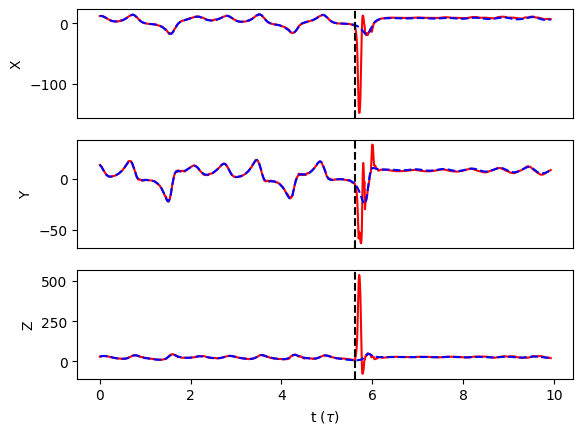


=== Conclusion ===
This example demonstrated the key steps of Reservoir Computing using the rescompy library:
1. Generating a dynamic time series (Lorenz system).
2. Creating features (time-delayed coordinates).
3. Initializing and training an ESN with the training data.
4. Using the trained ESN to make predictions on unseen test data.
The plot shows how the RC prediction (red dashed) tracks the ground truth (blue solid) over time.
The MSE provides a quantitative measure of the prediction accuracy.


In [17]:
# --- Explanation Text ---
print("=== Understanding Reservoir Computing ===\n")

print("1. Introduction:")
print("   Reservoir Computing (RC) is a machine learning framework designed for processing temporal data,")
print("   especially useful for tasks involving recurrent neural networks (RNNs) like time series prediction.\n")

print("2. Core Components:")
print("   a. Input Layer: Takes the external input signal and feeds it into the reservoir.")
print("   b. Reservoir (Hidden Layer): A large, fixed, randomly connected recurrent neural network.")
print("      - It has internal dynamics that respond to the input.")
print("      - The connections within the reservoir are typically random and remain unchanged during training.")
print("      - It's called a 'reservoir' because it holds a rich history of the input signal's influence.")
print("   c. Output (Readout) Layer: A typically linear model (like Ridge Regression) that is trained to map")
print("      the reservoir's internal states to the desired output.\n")

print("3. Process:")
print("   i.  Initialization: The reservoir's internal connections (weights) and bias are randomly set.")
print("       A crucial parameter is the 'spectral radius' (largest eigenvalue of the connection matrix),")
print("       which controls the reservoir's dynamics stability.")
print("   ii. Training Phase:")
print("       - Input data (e.g., a time series) is fed into the reservoir.")
print("       - The reservoir processes the input, creating a sequence of internal 'reservoir states'.")
print("       - A 'transient' period is usually discarded to let the reservoir settle.")
print("       - The readout layer is trained (e.g., using Ridge Regression) to map the reservoir states")
print("         to the target outputs (e.g., the next value in the time series).")
print("   iii. Prediction Phase:")
print("       - The trained readout weights are used.")
print("       - The system (or a new input) is fed into the reservoir again.")
print("       - The resulting reservoir states are multiplied by the trained readout weights to make predictions.\n")

print("4. Advantages:")
print("   - Training is simplified because only the readout layer is trained, not the complex recurrent connections.")
print("   - The fixed reservoir can capture complex, non-linear temporal features of the input.\n")

print("5. Application Example:")
print("   Here, we will use RC to predict the future states of a Lorenz system.")
print("   To make the task more interesting, we will use time-delayed coordinates of the system's variables")
print("   as the input features, making the prediction task more challenging and realistic.\n")

# --- Generate Time-Delayed Lorenz Data ---
print("--- Generating Time-Delayed Lorenz Dataset ---")

def lorenz_step(state, sigma=10, rho=28, beta=8/3, dt=0.01):
    """Calculate the next state of the Lorenz system."""
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([x + dx * dt, y + dy * dt, z + dz * dt])

# Parameters
dt = 0.01
N_transient = 1000 # Transient steps to discard from the generated trajectory
N_train = 3000     # Steps for training the RC
N_test = 1000      # Steps for testing the RC
delay_steps = 5    # Number of delay steps for feature creation
total_steps = N_transient + N_train + N_test # Total steps to generate

# Generate the full Lorenz trajectory
trajectory = np.zeros((total_steps, 3))
state = np.random.random(3) * 2 - 1  # Random initial state in [-1, 1]
for i in range(total_steps):
    trajectory[i] = state
    state = lorenz_step(state, dt=dt)

# --- Create Time-Delayed Features ---
print("Creating time-delayed features...")
# The input features will be [X(t), X(t-1), ..., X(t-delay)]
# We shift the trajectory to create the delayed versions
# Input shape: (available_steps, features)
# Target shape: (available_steps - 1, features) (predicting the next step)
X_full = np.zeros((total_steps - delay_steps, 3 * (delay_steps + 1)))
Y_full = trajectory[delay_steps + 1 : total_steps] # Target is the next step

for i in range(delay_steps + 1):
    start_idx = i * 3
    end_idx = start_idx + 3
    X_full[:, start_idx:end_idx] = trajectory[delay_steps - i : total_steps - i]

# Split into transient, train, and test sets for the *features*
# Length of X_full is total_steps - delay_steps
# Length of Y_full is total_steps - delay_steps - 1 (one less than X_full)
# After transient, available_steps_for_features = (total_steps - delay_steps) - N_transient
# X_train: N_train points
# Y_train: N_train points
# X_test: up to N_test - delay_steps points (to fit within available features)
# Y_test: N_test - delay_steps - 1 points (one less than X_test, needed for predict_length)

X_after_transient = X_full[N_transient:]
Y_after_transient = Y_full[N_transient:]

X_train = X_after_transient[:N_train]
Y_train = Y_after_transient[:N_train]

# Calculate maximum possible length for X_test based on available features
max_X_test_len = len(X_after_transient) - N_train # This is (N_train+N_test-delay_steps) - N_train = N_test - delay_steps
X_test_len = min(N_test - delay_steps, max_X_test_len) # Should be N_test - delay_steps

X_test = X_after_transient[N_train : N_train + X_test_len]
# Y_test corresponds to predicting the step *after* each input in X_test
# So Y_test starts where X_test starts (N_train after transient in feature space) and goes for X_test_len steps
# Y_after_transient[N_train : N_train + X_test_len]
# But for predict_length = len(X_test) - 1, we need Y_test to be one step shorter
Y_test_len = X_test_len - 1
Y_test = Y_after_transient[N_train : N_train + Y_test_len]

print(f"Trajectory shape: {trajectory.shape}")
print(f"X_full shape: {X_full.shape}")
print(f"Y_full shape: {Y_full.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}\n")

# --- Reservoir Computing Setup and Training ---
print("--- Setting up and Training the Reservoir Computer ---")

# Define ESN parameters based on the example
reservoir_size = 300
spectral_radius = 1.25
input_scaling = 1.0
bias_strength = 1.0 # Changed name to match example
leaking_rate = 1.0 # Changed name to match example

# 1. Initialize the ESN
print(f"1. Initializing ESN with size {reservoir_size}...")
# Use only the parameters from the working example
esn = rc.ESN(input_dimension=X_train.shape[1], # Number of features in input
             size=reservoir_size,
             spectral_radius=spectral_radius,
             leaking_rate=leaking_rate, # Use leaking_rate
             bias_strength=bias_strength, # Use bias_strength
             seed=42) # For reproducibility

# 2. Train the ESN
print("2. Training the ESN...")
# rescompy's train method handles driving and training the readout internally
train_result = esn.train(transient_length=1000, # Number of transient steps during training
                         inputs=X_train,
                         target_outputs=Y_train) # Target is the next state
print("Training completed.\n")

# --- Prediction Phase ---
print("--- Running Prediction Phase ---")

# Predict using the trained ESN
print("Predicting future states using the trained ESN...")
# Use the test input sequence to predict corresponding outputs
# We use the 'observer' mapper concept from the example, which feeds the true input at each step
# This is suitable for one-step prediction evaluation.
def observer_mapper(inputs, outputs):
    # For the prediction step, the input to the reservoir is just the external input
    # This is the standard 'observation' mode for comparison.
    return inputs

# Use the test inputs to drive the reservoir and generate predictions
predict_length = len(X_test) - 1 # Number of predictions to make
print(f"Predicting for {predict_length} steps using {len(X_test)} test inputs.")
# Ensure inputs and target_outputs lengths match the prediction logic
X_test_inputs = X_test[:-1] # Need len(X_test) - 1 inputs to make predict_length predictions
Y_test_targets = Y_test # This should now have length predict_length

print(f"  - Input sequence length for prediction: {len(X_test_inputs)}")
print(f"  - Target sequence length for comparison: {len(Y_test_targets)}")
print(f"  - Predict length specified: {predict_length}")

predict_result = esn.predict(train_result=train_result,
                             predict_length=predict_length,
                             inputs=X_test_inputs, # Use len(X_test) - 1 inputs
                             target_outputs=Y_test_targets, # Use the correctly sized target array
                             mapper=observer_mapper) # Use the observer mapper

# Get the predicted outputs from the predict_result object
Y_pred_from_object = predict_result.reservoir_outputs # This is the actual prediction
Y_target_from_object = predict_result.target_outputs # This is the ground truth

print(f"Prediction shape (from object): {Y_pred_from_object.shape}")
print(f"Target shape (from object): {Y_target_from_object.shape}\n")

# --- Visualization ---
print("--- Visualizing Results ---")

# Calculate MSE for quantitative assessment
# Use the MSE from the predict_result object
mse = np.mean(predict_result.rmse**2) # RMSE is per timestep per dimension, MSE is mean of RMSE^2
print(f"Mean Squared Error (MSE) on Test Set (from rescompy): {mse:.6f}\n")

# Use the rescompy plotter if available, otherwise fall back to manual
if PLOTTER_AVAILABLE:
    print("Using rescompy.plotter.plot_actual to visualize comparison...")
    try:
        rescompy.plotter.plot_actual(predict_result=predict_result, y_labels=['X', 'Y', 'Z'], tau=dt)
    except Exception as e:
        print(f"rescompy.plotter.plot_actual failed: {e}. Falling back to manual plot.")
        PLOTTER_AVAILABLE = False

if not PLOTTER_AVAILABLE:
    print("Using manual visualization (using data from predict_result object)...")
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    time_axis = np.arange(len(Y_target_from_object)) # Use length of the target/prediction array for x-axis

    for i, var_name in enumerate(['X', 'Y', 'Z']):
        axes[i].plot(time_axis, Y_target_from_object[:, i], label='Ground Truth', color='blue', alpha=0.7)
        axes[i].plot(time_axis, Y_pred_from_object[:, i], label='RC Prediction', color='red', linestyle='--', alpha=0.8)
        axes[i].set_ylabel(f'{var_name}')
        axes[i].legend()
        axes[i].grid(True)

    axes[-1].set_xlabel('Time Steps')
    axes[0].set_title(f'Lorenz System (Time-Delayed Features): Ground Truth vs. Reservoir Computing Prediction\n(MSE: {mse:.6f})')
    plt.tight_layout()
    plt.show()


print("\n=== Conclusion ===")
print("This example demonstrated the key steps of Reservoir Computing using the rescompy library:")
print("1. Generating a dynamic time series (Lorenz system).")
print("2. Creating features (time-delayed coordinates).")
print("3. Initializing and training an ESN with the training data.")
print("4. Using the trained ESN to make predictions on unseen test data.")
print("The plot shows how the RC prediction (red dashed) tracks the ground truth (blue solid) over time.")
print("The MSE provides a quantitative measure of the prediction accuracy.")

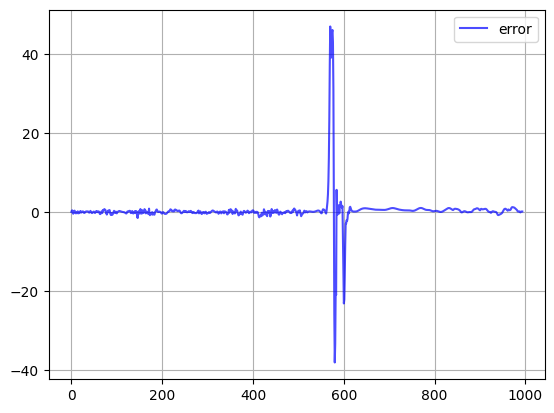

In [18]:
i=1
time_axis = np.arange(len(Y_target_from_object)) # Use length of the target/prediction array for x-axis
plt.plot(time_axis, Y_target_from_object[:, i] - Y_pred_from_object[:, i], label='error', color='blue', alpha=0.7)
plt.legend()
plt.grid()



--- Additional Visualization: 2D Phase Space Plot (X vs Y) ---
Plotting the target trajectory in the X-Y plane to show its structure...


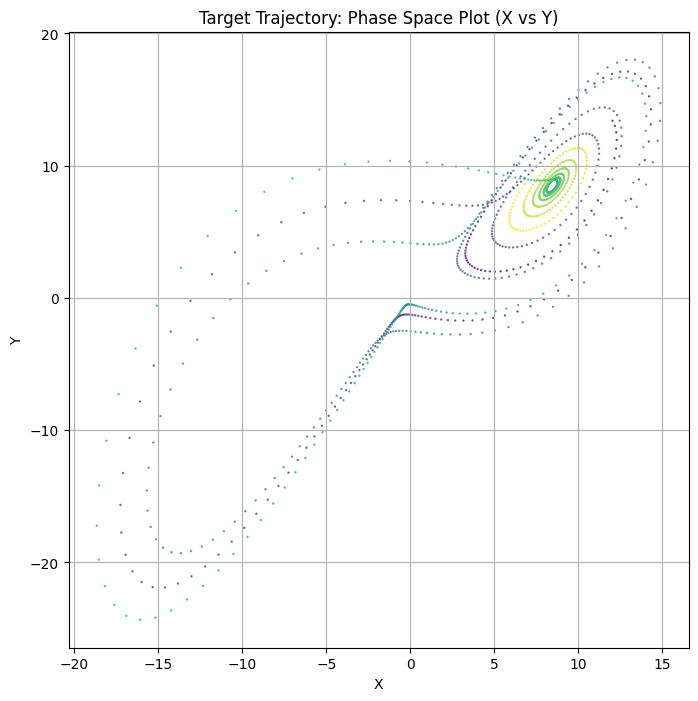

In [19]:
# --- Additional Visualization: 2D Phase Space Plot (X vs Y) ---
print("\n--- Additional Visualization: 2D Phase Space Plot (X vs Y) ---")
print("Plotting the target trajectory in the X-Y plane to show its structure...")
fig_2d, ax_2d = plt.subplots(figsize=(8, 8))
ax_2d.scatter(Y_target_from_object[:, 0], Y_target_from_object[:, 1], c=np.arange(len(Y_target_from_object)), cmap='viridis', s=0.5, alpha=0.7)
ax_2d.set_xlabel('X')
ax_2d.set_ylabel('Y')
ax_2d.set_title('Target Trajectory: Phase Space Plot (X vs Y)')
ax_2d.grid(True)
plt.show()